# SDE for generative modeling

The notebook implements generative modeling with a stochastic differential equation (SDE):
\begin{align*}
x_0 & \sim p_0(x_0)\\
dx & = f(x,t)\,dt + \sigma(x,t)\,dW\\
y & \sim p(y|x_1),
\end{align*}
where $p_0(x_0)=\mathcal{N}(x_0|0,1)$ and $dW \sim \mathcal{N}(dW| 0, dt)$. 

We learn $f(x,t)$ and $\sigma(x,t)$ jointly with a variational distribution
$q_t(x|y) = \mathcal{N}(x \mid \alpha(y,t),\, \beta^2(y,t))$
by maximizing the log likelihood lower bound (aka the ELBO):
$$
\log p(y) \;\ge\; \mathbb{E}_{q_1}\bigl[\log p(y|x_1)\bigr]
  - \mathrm{KL}\bigl(q_0(x|y) \;\|\; p_0(x) \bigr)
  - \int_0^1 \mathbb{E}_{q_t(x|y)}\left[ \frac{(f(x,t) - g(x,y,t))^2}{2\sigma^2(x,t)} \right]\,dt,
$$
where $g(x,y,t)$ is the drift implied by the variational distribution:
$$
g(x,y,t) = \frac{\partial \alpha(y,t)}{\partial t} + \frac{\partial \beta(y,t)}{\partial t} \frac{x-\alpha(y,t)}{\beta(y,t)} + \frac{1}{2} \frac{\partial^2 \sigma(x,t)}{\partial x^2} + \frac{\sigma^2(x,t)}{2} \frac{\partial \log q_t(x|y)}{\partial x}  \ .
$$
All learned functions are parameterised by neural networks. The path integral over $t$ is replaced by a stochastic estimate drawing $t$ from the uniform distribution on the unit interval.

We simulate data from a known one-dimensional distribution and take the likelihood function $p(y|x_1)$ to be a narrow Gaussian with mean $x_1$ and same width as the variational $\beta(y,1)$.

## Setup

In [1]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.system("wget -q https://raw.githubusercontent.com/olewinther/generative-ode-sde/main/utils.py")
else:
    for path in ['..', '.']:
        if os.path.exists(os.path.join(path, 'utils.py')):
            sys.path.insert(0, os.path.abspath(path))
            break

from utils import *

## GPU

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('GPU State:', device)

GPU State: cpu


## Network components

In [3]:
import torch.nn as nn

class DriftNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))


class DiffusionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x, t):
        return nn.Softplus()(self.net(torch.cat([x, t], dim=-1)))


class AlphaNetwork(nn.Module):
    """Variational mean: interpolates between a free network at t=0 and y at t=1."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, y, t):
        return t * y + (1 - t) * self.net(torch.cat([y, t], dim=-1))


class BetaNetwork(nn.Module):
    """Variational std: interpolates between a free network at t=0 and beta_lik at t=1."""
    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, y, t):
        return t * self.beta() + (1 - t) * nn.Softplus()(self.net(torch.cat([y, t], dim=-1)))


class Beta(nn.Module):
    """Shared learnable (or fixed) scalar beta used in BetaNetwork and Likelihood."""
    def __init__(self, initial_beta=1e-1, trainable=True):
        super().__init__()
        log_b = torch.log(torch.tensor(initial_beta))
        if trainable:
            self.log_beta = nn.Parameter(log_b)
        else:
            self.register_buffer("log_beta", log_b)

    def forward(self):
        return torch.exp(self.log_beta)


class Likelihood(nn.Module):
    def __init__(self, beta):
        super().__init__()
        self.beta = beta

    def log_prob(self, y, x):
        var = self.beta() ** 2
        return -0.5 * ((y - x) ** 2 / var + torch.log(2 * torch.pi * var))

    def sample(self, x):
        return x + torch.randn_like(x) * self.beta()

## Visualize network outputs

In [8]:
def plot_alpha_beta_f_sigma(alpha_net, beta_net, f_net, sigma_net, num_samples=3):
    t_grid = torch.linspace(0, 1, 100).unsqueeze(1)
    y_samples = torch.randn(num_samples, 1)
    x_samples = torch.randn(num_samples, 1)

    fig, axes = plt.subplots(4, 1, figsize=(10, 12))
    for ax, net, samples, ylabel, title, var_name in zip(
        axes,
        [alpha_net, beta_net, f_net, sigma_net],
        [y_samples, y_samples, x_samples, x_samples],
        ["alpha(y,t)", "beta(y,t)", "f(x,t)", "sigma(x,t)"],
        ["alpha(y,t)", "beta(y,t)", "f(x,t)", "sigma(x,t)"],
        ["y", "y", "x", "x"],
    ):
        for s in samples:
            vals = [net(s, t.expand_as(s)).item() for t in t_grid]
            ax.plot(t_grid.numpy(), vals, label=f"{var_name}={s.item():.2f}")
        ax.set_title(title); ax.set_xlabel("t"); ax.set_ylabel(ylabel); ax.legend()
    plt.tight_layout(); plt.show()

## SDE ELBO and training loop

In [5]:
def compute_elbo_sde(f_net, alpha_net, beta_net, sigma_net, prior, likelihood, y, t_sample):
    # 1. Likelihood term
    q_x1 = Variational(alpha_net, beta_net, y, torch.full(y.size(), 1.0))
    x_1 = q_x1.sample()
    likelihood_term = likelihood.log_prob(y, x_1)

    # 2. KL divergence term
    q_x0 = Variational(alpha_net, beta_net, y, torch.full(y.size(), 0.0))
    x_0 = q_x0.sample()
    kl_divergence = q_x0.log_prob(x_0) - prior.log_prob(x_0)

    # 3. Drift matching term
    t_sample.requires_grad = True
    q_xt = Variational(alpha_net, beta_net, y, t_sample)
    x_t = q_xt.sample()
    f_xt = f_net(x_t, t_sample)
    g_xt, sigma_squared = q_xt.drift(x_t, mode="sde", sigma_net=sigma_net)
    drift_matching_term = 0.5 * (f_xt - g_xt) ** 2 / sigma_squared

    elbo = likelihood_term - kl_divergence - drift_matching_term
    return elbo.mean(), likelihood_term.mean(), kl_divergence.mean(), drift_matching_term.mean()


def estimate_elbo_grid(f_net, alpha_net, beta_net, sigma_net, prior, likelihood, data, num_t_points=100):
    t_grid = torch.linspace(0, 1, num_t_points)
    elbo_t = []
    for t_val in t_grid:
        t = t_val.expand(data.size(0), 1).clone().detach()
        elbo, *_ = compute_elbo_sde(f_net, alpha_net, beta_net, sigma_net, prior, likelihood, data, t)
        elbo_t.append(elbo.item())
    plt.plot(t_grid.numpy(), elbo_t)
    plt.xlabel("t"); plt.ylabel("ELBO"); plt.title("ELBO as a function of t"); plt.show()
    return sum(elbo_t) / num_t_points


def training_loop_sde(f_net, alpha_net, beta_net, sigma_net, prior, likelihood, data_loader, validation_set,
                       n_epochs=1000, lr=1e-3):
    optimizer = torch.optim.Adam(
        list(f_net.parameters()) + list(alpha_net.parameters()) +
        list(beta_net.parameters()) + list(sigma_net.parameters()),
        lr=lr, weight_decay=1e-6,
    )
    for epoch in range(n_epochs):
        total_elbo = 0.0
        for y_batch in data_loader:
            optimizer.zero_grad()
            t_sample = torch.rand(y_batch.size(), requires_grad=True)
            elbo, *_ = compute_elbo_sde(f_net, alpha_net, beta_net, sigma_net, prior, likelihood, y_batch, t_sample)
            total_elbo += elbo.item()
            (-elbo).backward()
            optimizer.step()
        if epoch % 50 == 0 or epoch == n_epochs - 1:
            t = torch.rand(validation_set.size(), requires_grad=True)
            elbo_val, ll, kl, dm = compute_elbo_sde(
                f_net, alpha_net, beta_net, sigma_net, prior, likelihood, validation_set, t)
            print(f"Epoch {epoch:4d} | train {total_elbo/len(data_loader):.4f} | val {elbo_val:.4f} "
                  f"(ll={ll:.4f}, kl={kl:.4f}, dm={dm:.4f})")
    return f_net, sigma_net, alpha_net, beta_net

## Create training and validation data

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

n_samples, n_val = 1000, 8000

# Choose distribution: 'gaussian', 'laplace', 'laplace_mixture'
training_set_dist = 'laplace_mixture'

if training_set_dist == 'gaussian':
    params = {'mean': torch.tensor(-1.0), 'std': torch.tensor(2.0)}
elif training_set_dist == 'laplace':
    params = {'loc': torch.tensor(0.0), 'scale': torch.tensor(1.0)}
elif training_set_dist == 'laplace_mixture':
    params = {'k': 5, 'spacing': 4.0, 'scale': torch.tensor(1.0)}

training_set = TrainingSetWithLogLikelihood(training_set_dist, params)
training_data, ell_train = training_set.generate_training_data(n_samples)
validation_data, ell_val = training_set.generate_training_data(n_val)
print(f"{training_set_dist} | true log-likelihood: train={ell_train:.4f}, val={ell_val:.4f}")

## Run training

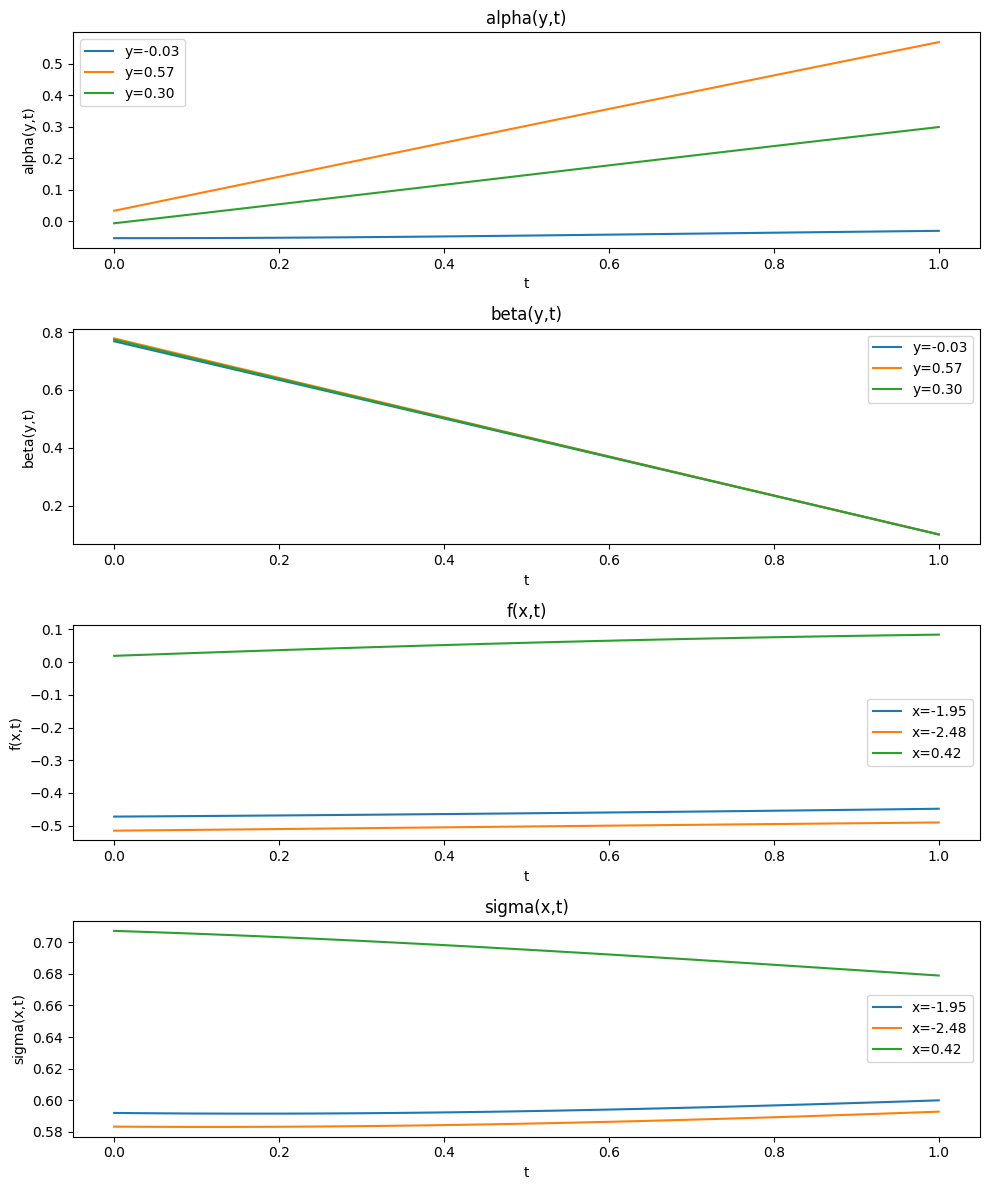

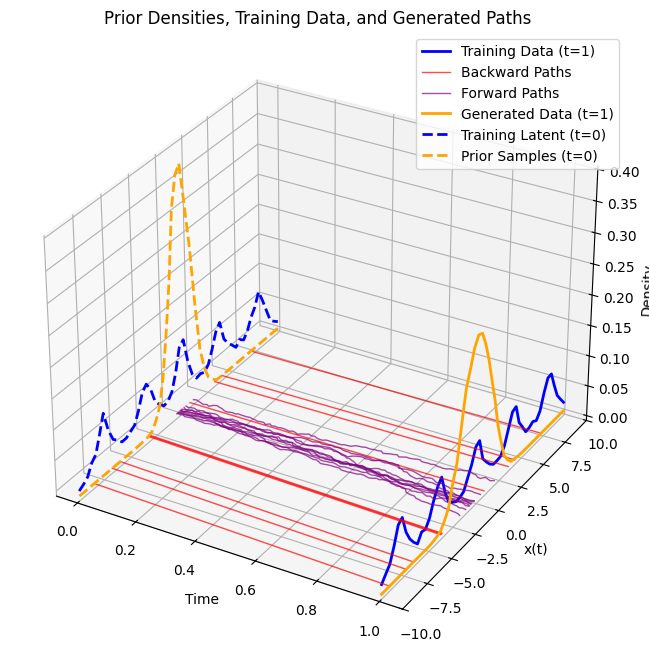

Epoch    0 | train -21.8579 | val -10.9007 (ll=0.8826, kl=1.1396, dm=10.6437)
Epoch   50 | train -3.3094 | val -3.2963 (ll=0.7007, kl=0.2983, dm=3.6986)
Epoch  100 | train -2.8770 | val -3.1256 (ll=0.6173, kl=0.3496, dm=3.3933)
Epoch  150 | train -3.6617 | val -3.1973 (ll=0.5901, kl=0.3727, dm=3.4147)
Epoch  200 | train -3.0278 | val -3.1946 (ll=0.5404, kl=0.4467, dm=3.2883)
Epoch  250 | train -3.0211 | val -3.3055 (ll=0.4795, kl=0.6674, dm=3.1176)
Epoch  300 | train -3.1095 | val -3.0829 (ll=0.4604, kl=0.4689, dm=3.0744)
Epoch  350 | train -3.3423 | val -3.1067 (ll=0.4332, kl=0.4223, dm=3.1177)
Epoch  400 | train -3.0513 | val -3.1071 (ll=0.3831, kl=0.4936, dm=2.9966)
Epoch  450 | train -2.9655 | val -3.0275 (ll=0.3933, kl=0.5864, dm=2.8344)
Epoch  500 | train -3.1211 | val -3.0899 (ll=0.3094, kl=0.6079, dm=2.7914)
Epoch  550 | train -2.9217 | val -3.0386 (ll=0.3018, kl=0.6114, dm=2.7291)
Epoch  600 | train -3.2846 | val -3.0650 (ll=0.2350, kl=0.6314, dm=2.6686)
Epoch  650 | train -3.

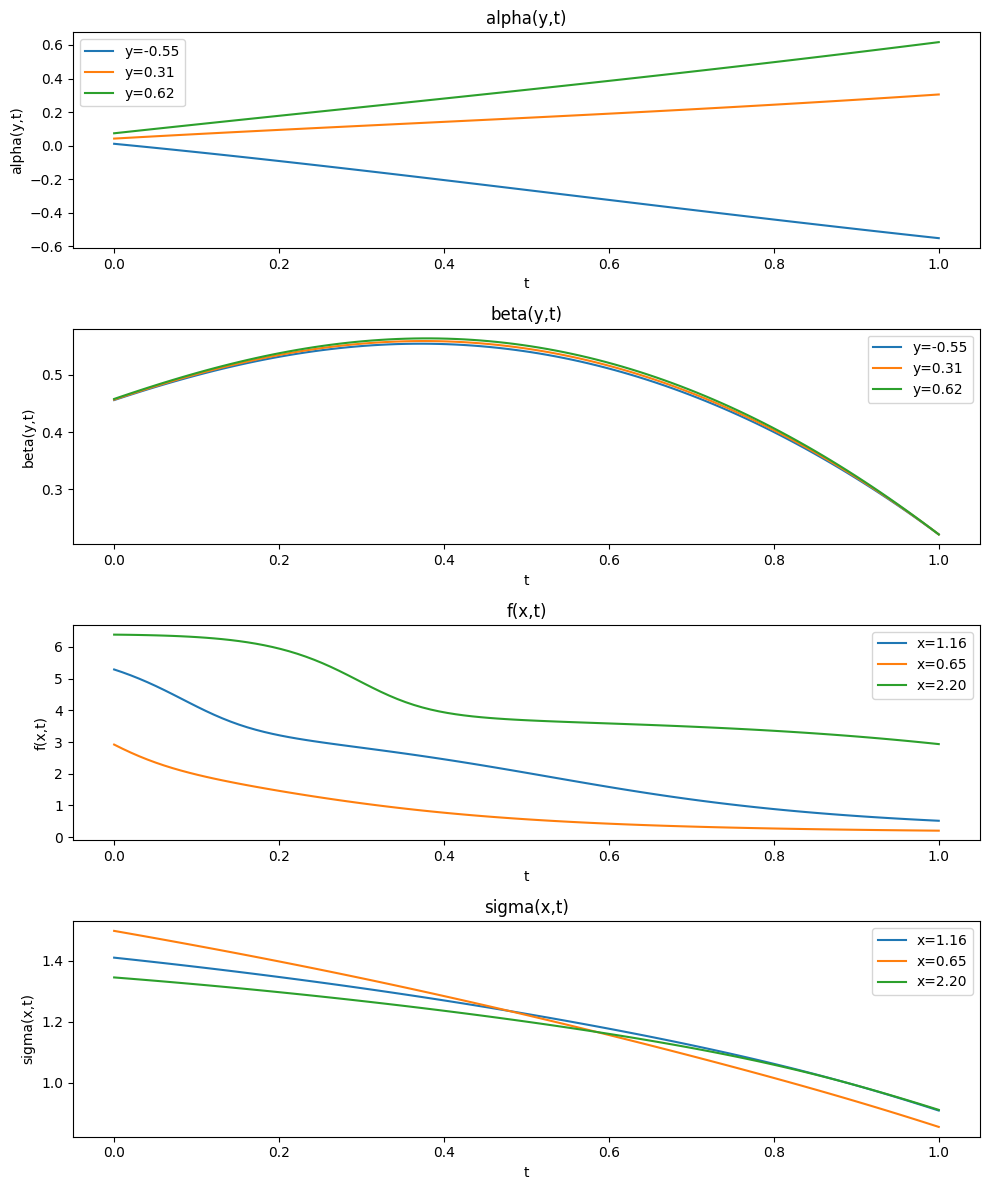

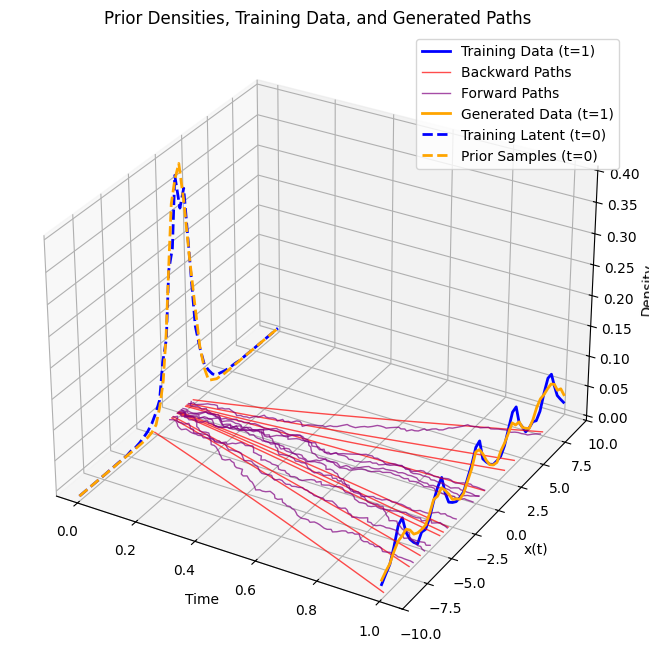

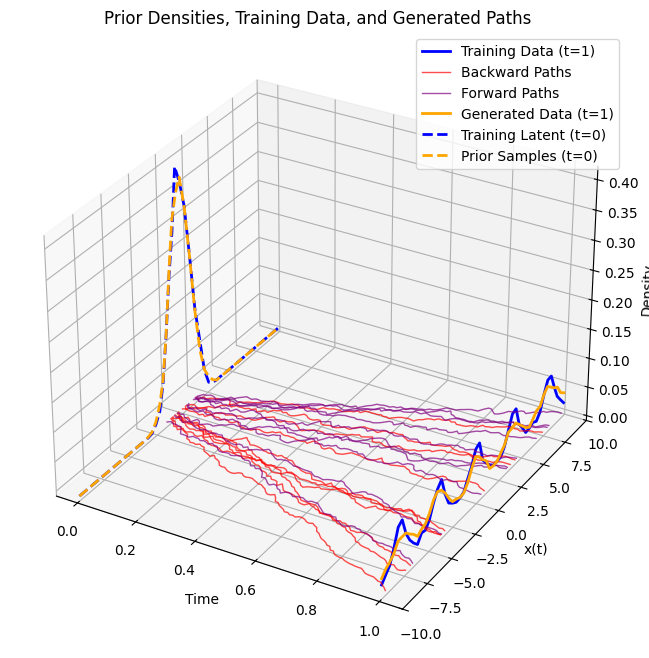

In [13]:
data_loader = torch.utils.data.DataLoader(training_data, batch_size=125, shuffle=True)

beta = Beta(initial_beta=1e-1, trainable=True)
f_net     = DriftNetwork()
sigma_net = DiffusionNetwork()
alpha_net = AlphaNetwork()
beta_net  = BetaNetwork(beta=beta)

prior          = Prior(gaussian_sample, gaussian_log_pdf)
likelihood_func = Likelihood(beta=beta)

t = torch.linspace(0, 1, steps=100)

forward_path  = ForwardPath(mode="sde", f_net=f_net, sigma_net=sigma_net,
                             prior=prior, likelihood_func=likelihood_func)
backward_path = BackwardPath(mode="ode", f_net=f_net, alpha_net=alpha_net,
                              beta_net=beta_net, sigma_net=sigma_net,
                              likelihood_func=likelihood_func)

plot_alpha_beta_f_sigma(alpha_net, beta_net, f_net, sigma_net, num_samples=3)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)

trained = training_loop_sde(
    f_net, alpha_net, beta_net, sigma_net,
    prior, likelihood_func, data_loader, validation_data,
    n_epochs=1000, lr=1e-3,
)

plot_alpha_beta_f_sigma(alpha_net, beta_net, f_net, sigma_net, num_samples=3)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)

backward_path_sde = BackwardPath(mode="backward sde", f_net=f_net, alpha_net=alpha_net,
                                  beta_net=beta_net, sigma_net=sigma_net,
                                  likelihood_func=likelihood_func)
visualize_paths_and_marginals(validation_data, t, backward_path_sde, forward_path)